In [1]:
###1 data exploratin and cleaning
###load the dataframeinto a paandasand display the first five rows

In [2]:
import pandas as pd
df = pd.read_csv("credit_card_transactions.csv")
df


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,Approved,Port Jennifer
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Approved,Port James
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Approved,Hawkinston
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,Approved,Matthewland
...,...,...,...,...,...,...,...,...,...,...
5495,105495,3262,2023-08-17,ATM,Apple Store,Travel,4554.82,Debit Card,Approved,South Hannahtown
5496,105496,1234,2023-08-18,POS,Uber,Travel,4118.51,Debit Card,Approved,South Courtney
5497,105497,3978,2023-08-18,Online,Apple Store,Clothing,2981.13,UPI,Approved,Rubenton
5498,105498,3082,2023-08-18,ATM,Uber,Clothing,2168.39,Debit Card,Approved,East Brianfurt


In [3]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,Approved,Port Jennifer
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Approved,Port James
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Approved,Hawkinston
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,Approved,Matthewland


In [4]:
#####check the shape ,column names and summary statistic of the dataset
print (df.shape) ###rows columns
print (df.columns.to_list())
print ('summary stastics\n',df.describe()) ###include = 'all'

(5500, 10)
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Type', 'Merchant', 'Category', 'Amount', 'Payment_Mode', 'Transaction_Status', 'Location']
summary stastics
        Transaction_ID  Customer_ID       Amount
count     5500.000000  5500.000000  5490.000000
mean    102749.500000  2989.954182  2491.062299
std       1587.857571  1153.928878  1444.542432
min     100000.000000  1000.000000     6.550000
25%     101374.750000  1988.000000  1236.402500
50%     102749.500000  3000.000000  2502.405000
75%     104124.250000  3990.000000  3765.420000
max     105499.000000  4998.000000  4997.490000


In [5]:
df.dtypes

Transaction_ID          int64
Customer_ID             int64
Transaction_Date       object
Transaction_Type       object
Merchant               object
Category               object
Amount                float64
Payment_Mode           object
Transaction_Status     object
Location               object
dtype: object

In [6]:
###indetifyig misssing values (fill or drop based on data type )
print (df.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       1
Merchant               2
Category               5
Amount                10
Payment_Mode           3
Transaction_Status     2
Location               0
dtype: int64


In [7]:
df['Merchant'] = df['Merchant'].fillna('Unknown')
df['Transaction_Status'] = df['Transaction_Type'].fillna('Unknown')
df['Category'] = df['Category'].fillna('Unknown')
df['Payment_Mode'] = df['Payment_Mode'].fillna('Unknown')
df['Transaction_Type'] = df['Transaction_Type'].fillna('Unknown')
print (df.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       0
Merchant               0
Category               0
Amount                10
Payment_Mode           0
Transaction_Status     0
Location               0
dtype: int64


In [8]:
###fill in the valuesdf
df['Amount'] = df['Amount'].fillna(df['Amount'].median())
print(df.isnull().sum())

Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Transaction_Type      0
Merchant              0
Category              0
Amount                0
Payment_Mode          0
Transaction_Status    0
Location              0
dtype: int64


In [9]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'],errors='coerce')
print(df.dtypes)

Transaction_ID                 int64
Customer_ID                    int64
Transaction_Date      datetime64[ns]
Transaction_Type              object
Merchant                      object
Category                      object
Amount                       float64
Payment_Mode                  object
Transaction_Status            object
Location                      object
dtype: object


In [10]:
######year month date 
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Day'] = df['Transaction_Date'].dt.day

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      5500 non-null   int64         
 1   Customer_ID         5500 non-null   int64         
 2   Transaction_Date    5500 non-null   datetime64[ns]
 3   Transaction_Type    5500 non-null   object        
 4   Merchant            5500 non-null   object        
 5   Category            5500 non-null   object        
 6   Amount              5500 non-null   float64       
 7   Payment_Mode        5500 non-null   object        
 8   Transaction_Status  5500 non-null   object        
 9   Location            5500 non-null   object        
 10  Year                5500 non-null   int32         
 11  Month               5500 non-null   int32         
 12  Day                 5500 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int6

In [11]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Online,Jonesport,2023,1,1
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,ATM,Port Jennifer,2023,1,1
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Mobile Payment,Port James,2023,1,1
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Online,Hawkinston,2023,1,1
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,ATM,Matthewland,2023,1,1


In [12]:
df.to_csv("clean_data.csv")

In [13]:
###data selection and indexing
###retrive all tranctaionsmade in jan 2024

In [14]:
###retrive all tranctaionsmade in jan 2024
jan_24 = df[(df['Year'] == 2023) & (df['Month'] == 1)]
print(jan_24.count())
jan_24.to_csv("jan_24.csv",index=False)


Transaction_ID        744
Customer_ID           744
Transaction_Date      744
Transaction_Type      744
Merchant              744
Category              744
Amount                744
Payment_Mode          744
Transaction_Status    744
Location              744
Year                  744
Month                 744
Day                   744
dtype: int64


In [15]:
###find the transctons where amount > 1000 and transcation type is online 
####select only approved transcation from the dataset
high_transactions = df[(df['Amount'] > 3000) & (df['Transaction_Type'] == "Online")]
high_transactions.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Online,Jonesport,2023,1,1
22,100022,3057,2023-01-01,Online,BestBuy,Groceries,4094.49,PayPal,Online,West Kenneth,2023,1,1
26,100026,4254,2023-01-02,Online,BestBuy,Travel,4054.78,Credit Card,Online,Stevensmouth,2023,1,2
27,100027,1719,2023-01-02,Online,Walmart,Entertainment,4471.68,UPI,Online,Riveramouth,2023,1,2
34,100034,2424,2023-01-02,Online,Target,Groceries,4074.73,PayPal,Online,North Marytown,2023,1,2


In [16]:
approved_transaction = df[df['Transaction_Status'] == 'Online']
approved_transaction.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Online,Jonesport,2023,1,1
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Online,Hawkinston,2023,1,1
6,100006,1587,2023-01-01,Online,Netflix,Entertainment,2309.06,Debit Card,Online,Scottport,2023,1,1
14,100014,1855,2023-01-01,Online,Walmart,Clothing,2365.67,Credit Card,Online,Catherineland,2023,1,1
18,100018,4438,2023-01-01,Online,BestBuy,Dining,2930.38,UPI,Online,Johnsonside,2023,1,1


In [17]:
#####new column discounted amount 5% discount on all transaction above $4500.
df['Discounted_Amount'] = df['Amount'].apply(lambda x : x * 0.95 if x > 4500 else x)
df[['Amount','Discounted_Amount']].head()

,Amount,Discounted_Amount
0,4520.70,4294.665
1,1437.85,1437.850
2,3320.52,3320.520
3,2659.96,2659.960
4,2517.07,2517.070


In [18]:
####categorize the transaction into low medium and high based on 
###low below 2000
###medium between 2000 - 45000
###high above 4500
df['Amount_Category'] = pd.cut(df['Amount'],
                              bins=[-float('inf'),2000,4500,float('inf')],
                               labels=['low','medium','high'])
df[['Amount','Amount_Category']].head()
#### drop the merchant column if more than 30% of values are missing

missing_value = df['Merchant'].isnull().mean()
print(missing_value)

if missing_value > 0.03:
    df.drop(columns=['Merchant'],inplace=True)
    print("delete done...")
else:
    print("no missing value...")


0.0
no missing value...


In [19]:
#####find the total trancation amount per category
total_amount_per_category = df.groupby('Category')['Amount'].sum().reset_index()
total_amount_per_category

,Category,Amount
0,Clothing,2183340.875
1,Dining,2400761.790
2,Electronics,2312580.580
3,Entertainment,2245125.780
4,Groceries,2379876.120
5,Travel,2168738.345
6,Unknown,10532.580


In [20]:
####determine the number of declined transaction per paymenet mode
declined_transactions = df[df['Transaction_Status']=='Approved'].groupby('Payment_Mode').size().reset_index(name='declined_count')
declined_transactions

,Payment_Mode,declined_count


In [21]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Online,Jonesport,2023,1,1,4294.665,high
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,ATM,Port Jennifer,2023,1,1,1437.850,low
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Mobile Payment,Port James,2023,1,1,3320.520,medium
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Online,Hawkinston,2023,1,1,2659.960,medium
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,ATM,Matthewland,2023,1,1,2517.070,medium


In [22]:
###find the average transcation per location
avg_amount_loc = df.groupby('Location')['Amount'].mean().reset_index()
avg_amount_loc

,Location,Amount
0,Aaronfort,2429.860
1,Aaronmouth,2648.060
2,Aaronside,315.540
3,Abbottbury,1549.850
4,Abigailfort,3634.880
...,...,...
4658,Zacharyburgh,2430.690
4659,Zacharyhaven,830.360
4660,Zacharymouth,3508.690
4661,Zacharystad,2925.135


In [23]:
####5 top merchants based on transcation count(amount)
print(df.columns)
top_merchants = df['Merchant'].value_counts().head(5).reset_index()
top_merchants

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Type',
       'Merchant', 'Category', 'Amount', 'Payment_Mode', 'Transaction_Status',
       'Location', 'Year', 'Month', 'Day', 'Discounted_Amount',
       'Amount_Category'],
      dtype='object')


,Merchant,count
0,Uber,833
1,Walmart,818
2,BestBuy,790
3,Netflix,774
4,Amazon,769


In [24]:
####Find customers who made more than 10 transactions in a single day (potential fraud).(5)
##Identify transactions that have the same Customer_ID but occurred in different locations within 5 minutes.
####Find transactions where Amount > $5000 and Transaction_Type is Online (flag as high-risk).

In [25]:
#####load customer info csv
import pandas as pd
customer_info = pd.read_csv("customer_details.csv")
customer_info.head()

,Customer_ID,Age,Gender,Membership_Level
0,1001,58,Male,Silver
1,1002,35,Male,Silver
2,1003,65,Male,Gold
3,1004,52,Male,Gold
4,1005,20,Male,Silver


In [26]:
### Data Merging and Joining
###Suppose you have another dataset (customer_info.csv) containing Customer_ID, Age, Gender, and Account_Status.
##Merge it with credit_card_transactions.csv using an appropriate join operation.
###Find the average transaction amount per Age group.

In [27]:
merged_df = pd.merge(df,customer_info,on='Customer_ID',how='inner')
merged_df
merged_df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category,Age,Gender,Membership_Level
0,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,ATM,Port Jennifer,2023,1,1,1437.85,low,46,Male,Silver
1,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Mobile Payment,Port James,2023,1,1,3320.52,medium,18,Female,Gold
2,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,ATM,Matthewland,2023,1,1,2517.07,medium,48,Male,Silver
3,100006,1587,2023-01-01,Online,Netflix,Entertainment,2309.06,Debit Card,Online,Scottport,2023,1,1,2309.06,medium,36,Female,Platinum
4,100007,2103,2023-01-01,ATM,Uber,Dining,334.82,PayPal,ATM,Shawview,2023,1,1,334.82,low,29,Male,Silver


In [28]:
###Find the average transaction amount per Age group.
age_bin = [0,18,30,50,100]
age_labels = ['<18','18-30','31-50','>50']
merged_df['Age_group'] = pd.cut(merged_df['Age'],bins=age_bin,labels=age_labels,include_lowest=True)
avg_amount_per_age_group = merged_df.groupby('Age_group')['Amount'].mean().reset_index()
avg_amount_per_age_group

C:\Users\user\AppData\Local\Temp\ipykernel_2532\3637823379.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_amount_per_age_group = merged_df.groupby('Age_group')['Amount'].mean().reset_index()


,Age_group,Amount
0,<18,2746.317647
1,18-30,2437.124325
2,31-50,2491.450375
3,>50,2524.298427


In [29]:
##Find customers who made more than 10 transactions in a single day (potential fraud).
##Identify transactions that have the same Customer_ID but occurred in different locations within 5 minutes.
##Find transactions where Amount > $5000 and Transaction_Type is Online (flag as high-risk).

In [30]:
##Find customers who made more than 10 transactions in a single day (potential fraud).

In [31]:
##Find transactions where Amount > $5000 and Transaction_Type is Online (flag as high-risk).
high_risk = df[(df['Amount'] > 4900) & (df['Transaction_Type'] == 'Online')]
high_risk

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category
180,100180,3929,2023-01-08,Online,Uber,Travel,4947.09,UPI,Online,Port Scottshire,2023,1,8,4699.7355,high
279,100279,2049,2023-01-12,Online,Uber,Travel,4924.77,UPI,Online,Ryanside,2023,1,12,4678.5315,high
283,100283,4665,2023-01-12,Online,Amazon,Travel,4958.69,UPI,Online,Lake Nicholeville,2023,1,12,4710.7555,high
477,100477,4429,2023-01-20,Online,Target,Travel,4923.44,UPI,Online,Shannonside,2023,1,20,4677.2680,high
538,100538,3228,2023-01-23,Online,Amazon,Dining,4946.89,Credit Card,Online,Michelletown,2023,1,23,4699.5455,high
751,100751,3541,2023-02-01,Online,Netflix,Groceries,4962.50,Debit Card,Online,West Samanthahaven,2023,2,1,4714.3750,high
1282,101282,3878,2023-02-23,Online,Apple Store,Entertainment,4903.52,UPI,Online,Shawville,2023,2,23,4658.3440,high
1458,101458,3417,2023-03-02,Online,BestBuy,Electronics,4989.76,PayPal,Online,Harperborough,2023,3,2,4740.2720,high
1493,101493,2409,2023-03-04,Online,Walmart,Electronics,4976.10,UPI,Online,New Susanchester,2023,3,4,4727.2950,high
1575,101575,1321,2023-03-07,Online,Target,Travel,4987.09,PayPal,Online,Robertberg,2023,3,7,4737.7355,high


C:\Users\user\AppData\Local\Temp\ipykernel_2532\872067910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(total_amount_per_category,x="Category",y="Amount",palette="viridis")


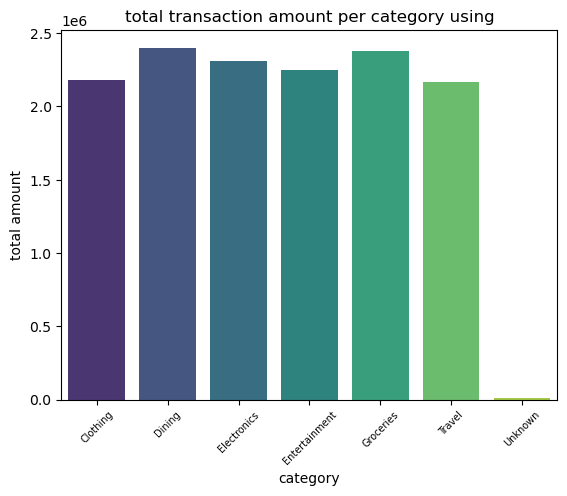

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(total_amount_per_category,x="Category",y="Amount",palette="viridis")
plt.title("total transaction amount per category using")
plt.xlabel("category")
plt.xticks(rotation=45,fontsize=7)
plt.ylabel("total amount")
plt.show()
